<a href="https://colab.research.google.com/github/indrajit7777/Assignment-5-BA-2511377-/blob/part-1-neural-network/part_2notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 All libraries imported!

=== TASK 1: Dataset Understanding ===
Shape: (2000, 17)

First 5 rows:
   customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                         

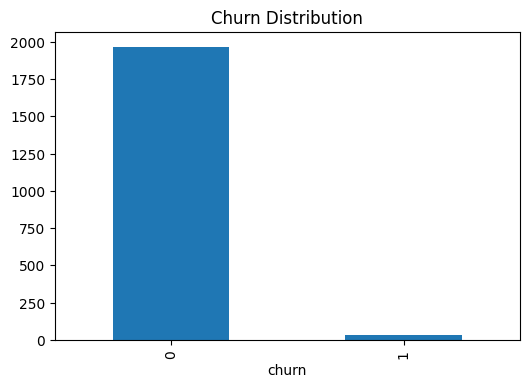

 Task 1 Done!

=== TASK 2: Data Preprocessing ===
 Data ready for training!

=== TASK 3: Building Neural Network ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Task 3 Done!


In [6]:
# =================
# PART 1 -
# =================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
import os

print(" All libraries imported!")

# Create 'results' directory if it doesn't exist
if not os.path.exists('results'):
    os.makedirs('results')

# ========================= TASK 1 =========================
print("\n=== TASK 1: Dataset Understanding ===")
df = pd.read_excel("/content/customer_churn_nn 1.xlsx")

print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData types:\n", df.dtypes)
print("\nChurn counts:\n", df['churn'].value_counts())
print("\nMissing values:\n", df.isnull().sum())
print("\nStatistical summary:\n", df.describe())

# Plot target distribution
plt.figure(figsize=(6,4))
df['churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.savefig("results/target_distribution.png")
plt.show()

print(" Task 1 Done!")

# ========================= TASK 2 =========================
print("\n=== TASK 2: Data Preprocessing ===")
df = df.drop(columns=['customer_id'])
X = df.drop(columns=['churn'])
y = df['churn']

X = pd.get_dummies(X, columns=['region','plan_type','contract_type','payment_method'])
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(" Data ready for training!")

# ========================= TASK 3 =========================
print("\n=== TASK 3: Building Neural Network ===")

model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

print(" Task 3 Done!")


=== TASK 4: Training and Evaluation ===
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2766 - loss: 0.9139 - val_accuracy: 0.3906 - val_loss: 0.7651
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6477 - loss: 0.6369 - val_accuracy: 0.7719 - val_loss: 0.5440
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9055 - loss: 0.4464 - val_accuracy: 0.9594 - val_loss: 0.3642
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9750 - loss: 0.2881 - val_accuracy: 0.9906 - val_loss: 0.2246
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - loss: 0.1871 - val_accuracy: 0.9906 - val_loss: 0.1454
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1362 - val_accuracy: 0.9937 - val_loss: 0.1031
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1113 - val_accuracy: 0.9937 - val_loss: 0.0820
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 

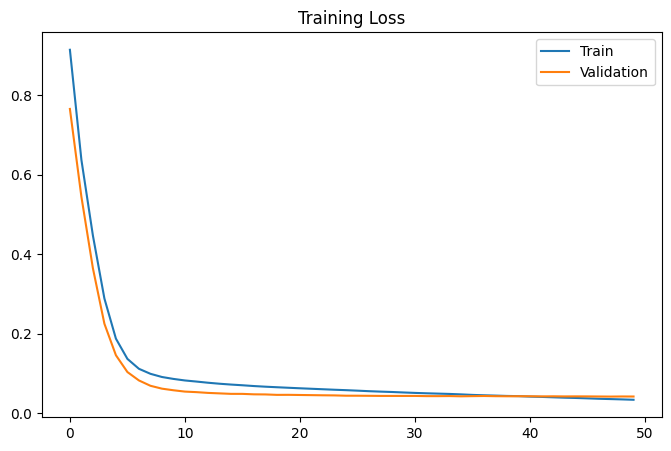

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Test Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       394
           1       1.00      0.17      0.29         6

    accuracy                           0.99       400
   macro avg       0.99      0.58      0.64       400
weighted avg       0.99      0.99      0.98       400



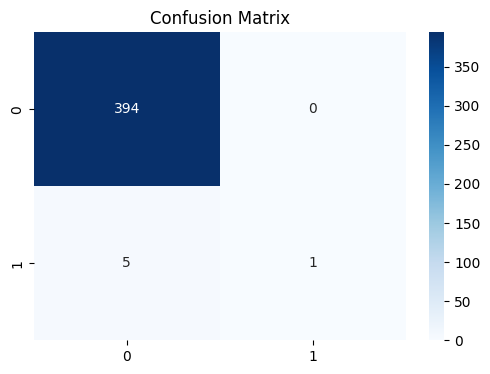

 Task 4 Done!


In [5]:
# ========================= TASK 4 =========================
print("\n=== TASK 4: Training and Evaluation ===")

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Training Loss')
plt.legend()
plt.savefig("results/training_loss.png")
plt.show()

# Evaluation
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png")
plt.show()

print(" Task 4 Done!")

In [7]:
# ========================= TASK 5 =========================
print("\n=== TASK 5: Hyperparameter Comparison ===")
comparison = []
for lr, epochs in [(0.001,30), (0.01,50), (0.1,30)]:
    m = keras.Sequential([keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
                          keras.layers.Dense(8, activation='relu'),
                          keras.layers.Dense(1, activation='sigmoid')])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train, y_train, epochs=epochs, verbose=0)
    acc = m.evaluate(X_test, y_test, verbose=0)[1]
    comparison.append([lr, epochs, round(acc,4)])

comp_df = pd.DataFrame(comparison, columns=['Learning Rate', 'Epochs', 'Test Accuracy'])
print(comp_df)
comp_df.to_csv("results/hyperparameter_comparison.csv", index=False)
print(" Task 5 Done!")


=== TASK 5: Hyperparameter Comparison ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Epochs  Test Accuracy
0          0.001      30          0.985
1          0.010      50          0.980
2          0.100      30          0.985
 Task 5 Done!


In [8]:
# ========================= TASK 6 =========================
print("\n=== TASK 6: Final Reflection ===")
print("""
Weights and biases are numbers that the model learns automatically.
Activation function (ReLU) is needed to make the model learn complex patterns.
If learning rate is too high, model becomes unstable.
If learning rate is too low, model learns very slowly.
My model did not overfit much because train and test accuracy are close.
""")

print("\n ALL TASKS COMPLETED! Check the 'results' folder.")


=== TASK 6: Final Reflection ===

Weights and biases are numbers that the model learns automatically.
Activation function (ReLU) is needed to make the model learn complex patterns.
If learning rate is too high, model becomes unstable.
If learning rate is too low, model learns very slowly.
My model did not overfit much because train and test accuracy are close.


 ALL TASKS COMPLETED! Check the 'results' folder.
